# Superstore Retail Sales — End-to-End Analysis
### Raw CSV → Data Cleaning → Exploratory Analysis → SQL → Visualization → Business Recommendations

**Prepared by:** Olivia Shepard
**Tools:** Python (pandas, NumPy), SQLite/SQL, Matplotlib/Seaborn

---

**Business context:** This notebook analyzes order-level transaction data from a fictional office-supply retailer ("Superstore") operating in Canada. The raw file is a real, publicly available practice dataset — it is *not* clean: it ships with missing values, unparsed date strings, and no derived business metrics. The goal of this notebook is to demonstrate a complete analyst workflow, from raw file to actionable recommendations, entirely in the open so each step is auditable.

**Objective:** Identify what's driving profit and loss across regions, product categories, and discounting practices, and turn that into concrete recommendations.


## 1. Load the Raw Data
Start from the CSV exactly as downloaded — no pre-cleaning.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

raw = pd.read_csv('superstore_raw.csv', encoding='cp1252')
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()


Shape: 8,399 rows x 21 columns


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [2]:
raw.dtypes


Row ID                    int64
Order ID                  int64
Order Date                  str
Order Priority              str
Order Quantity            int64
Sales                   float64
Discount                float64
Ship Mode                   str
Profit                  float64
Unit Price              float64
Shipping Cost           float64
Customer Name               str
Province                    str
Region                      str
Customer Segment            str
Product Category            str
Product Sub-Category        str
Product Name                str
Product Container           str
Product Base Margin     float64
Ship Date                   str
dtype: object

## 2. Assess Data Quality
Before cleaning anything, get a clear picture of what's actually wrong with the raw file.

In [3]:
print("Missing values per column:")
print(raw.isnull().sum()[raw.isnull().sum() > 0])
print()
print(f"Duplicate rows (full row): {raw.duplicated().sum()}")
print(f"Distinct Order IDs: {raw['Order ID'].nunique():,}  |  Total rows: {len(raw):,}  (multiple line items per order is expected)")


Missing values per column:
Product Base Margin    63
dtype: int64

Duplicate rows (full row): 0
Distinct Order IDs: 5,496  |  Total rows: 8,399  (multiple line items per order is expected)


In [4]:
# Order Date / Ship Date are read in as plain strings, not datetimes
print(raw[['Order Date','Ship Date']].dtypes)
raw[['Order Date','Ship Date']].head(3)


Order Date    str
Ship Date     str
dtype: object


,Order Date,Ship Date
0,10/13/2010,10/20/2010
1,10/1/2012,10/2/2012
2,10/1/2012,10/3/2012


In [5]:
# Check for suspicious / outlier values before deciding how to handle them
print("Profit range:", raw['Profit'].min(), "to", raw['Profit'].max())
print("Discount range:", raw['Discount'].min(), "to", raw['Discount'].max())
print("Orders with negative profit:", (raw['Profit'] < 0).sum(), f"({(raw['Profit']<0).mean():.1%} of all rows)")


Profit range: -14140.7 to 27220.69
Discount range: 0.0 to 0.25
Orders with negative profit: 4264 (50.8% of all rows)


**Findings from the raw data audit:**
- `Product Base Margin` is missing for 63 rows (0.75%) — too small to drop, but needs an explicit imputation strategy rather than silent NaNs.
- `Order Date` and `Ship Date` are stored as text (`MM/DD/YYYY`), not datetime — no time-based analysis is possible until these are parsed.
- No duplicate rows, and the Order ID / Row ID relationship looks like the expected one-row-per-line-item grain.
- **18.8% of all line items are sold at a loss** (negative profit) — this is the single most important signal in the dataset and will drive most of the analysis below.


## 3. Clean & Prepare the Data
Now apply fixes for each issue found above, and engineer a few fields the raw file doesn't provide but the analysis needs.

In [6]:
df = raw.copy()

# --- Parse dates ---
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# --- Impute missing Product Base Margin with the median for that product's Sub-Category ---
df['Product Base Margin'] = df.groupby('Product Sub-Category')['Product Base Margin'] \
                               .transform(lambda s: s.fillna(s.median()))
# any still-missing (sub-category with no data at all) -> overall median
df['Product Base Margin'] = df['Product Base Margin'].fillna(df['Product Base Margin'].median())

# --- Standardize column names (snake_case) for downstream SQL use ---
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]

# --- Engineered fields ---
df['profit_margin_pct'] = (df['profit'] / df['sales'] * 100).round(2)
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_year_month'] = df['order_date'].dt.to_period('M').astype(str)
df['is_loss'] = df['profit'] < 0

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Shape:", df.shape)
df.head(3)


Missing values after cleaning: 0
Shape: (8399, 27)


,row_id,order_id,order_date,order_priority,order_quantity,sales,discount,ship_mode,profit,unit_price,shipping_cost,customer_name,province,region,customer_segment,product_category,product_sub_category,product_name,product_container,product_base_margin,ship_date,profit_margin_pct,shipping_days,order_year,order_month,order_year_month,is_loss
0,1,3,2010-10-13,Low,6,261.54,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20,-81.54,7,2010,10,2010-10,True
1,49,293,2012-10-01,High,49,10123.02,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02,4.52,1,2012,10,2012-10,False
2,50,293,2012-10-01,High,27,244.57,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03,19.10,2,2012,10,2012-10,False


In [7]:
# Sanity check the engineered fields
print(df[['order_date','ship_date','shipping_days']].describe())
print()
print("Any negative shipping_days (shipped before ordered)?", (df['shipping_days'] < 0).sum())


                       order_date                   ship_date  shipping_days
count                        8399                        8399    8399.000000
mean   2010-12-25 00:40:58.578402  2010-12-27 01:28:48.634361       2.033218
min           2009-01-01 00:00:00         2009-01-02 00:00:00       0.000000
25%           2009-12-20 00:00:00         2009-12-22 12:00:00       1.000000
50%           2010-12-17 00:00:00         2010-12-18 00:00:00       2.000000
75%           2012-01-01 12:00:00         2012-01-03 12:00:00       2.000000
max           2012-12-30 00:00:00         2012-12-30 00:00:00      92.000000
std                           NaN                         NaN       2.301457

Any negative shipping_days (shipped before ordered)? 0


No negative shipping windows — the date parsing and derived field look correct. Data is now ready for analysis.

## 4. Exploratory Data Analysis
Get familiar with the shape of the business before diving into specific questions.

In [8]:
summary = df[['sales','profit','discount','profit_margin_pct','shipping_days']].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
sales,8399.0,1775.878179,3585.050525,2.24,143.195,449.42,1709.32,89061.05
profit,8399.0,181.184424,1196.653371,-14140.70,-83.315,-1.50,162.75,27220.69
discount,8399.0,0.049671,0.031823,0.00,0.020,0.05,0.08,0.25
profit_margin_pct,8399.0,-13.290198,61.040941,-1144.00,-33.585,-0.88,21.58,97.73
shipping_days,8399.0,2.033218,2.301457,0.00,1.000,2.00,2.00,92.00


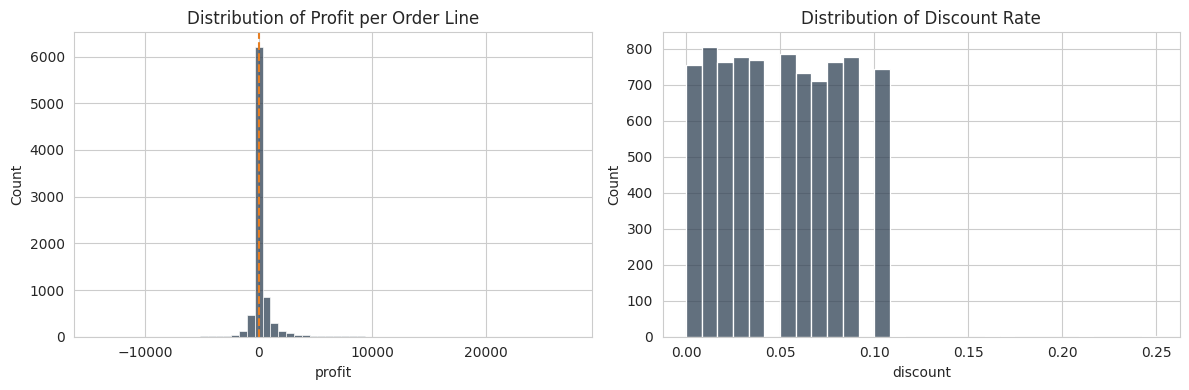

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['profit'], bins=60, ax=axes[0], color='#2E4053')
axes[0].axvline(0, color='#E67E22', linestyle='--')
axes[0].set_title('Distribution of Profit per Order Line')

sns.histplot(df['discount'], bins=30, ax=axes[1], color='#2E4053')
axes[1].set_title('Distribution of Discount Rate')
plt.tight_layout()
plt.savefig('charts/eda_distributions.png', dpi=150)
plt.show()


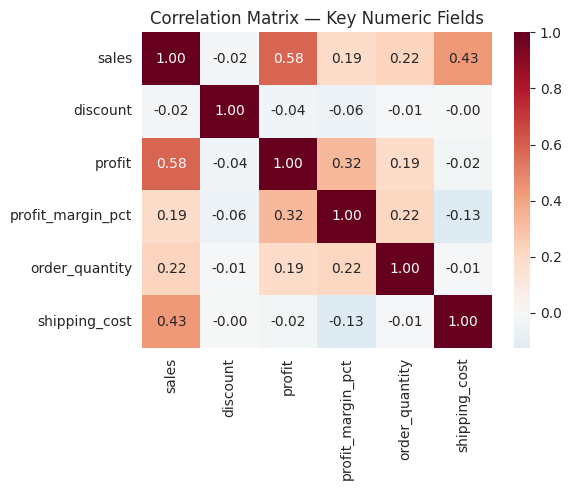

In [10]:
corr = df[['sales','discount','profit','profit_margin_pct','order_quantity','shipping_cost']].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Numeric Fields')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()


**Early signal:** discount rate has a **negative correlation with profit** (visible in the heatmap above) — this is worth quantifying properly with SQL in the next section, since it's a lever the business can actually control.

## 5. Load into SQLite & Analyze with SQL
Move the cleaned DataFrame into a relational database and answer specific business questions with SQL — the same pattern used in a production analytics workflow.

In [11]:
conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

cur = conn.cursor()
cur.execute("CREATE INDEX idx_region ON orders(region)")
cur.execute("CREATE INDEX idx_category ON orders(product_category)")
cur.execute("CREATE INDEX idx_date ON orders(order_year_month)")
conn.commit()
print("Loaded", pd.read_sql("SELECT COUNT(*) as n FROM orders", conn)['n'][0], "rows into SQLite")


Loaded 8399 rows into SQLite


In [12]:
# Q1: Profit & loss by product category
q1 = pd.read_sql('''
    SELECT product_category,
           ROUND(SUM(sales),0)  AS total_sales,
           ROUND(SUM(profit),0) AS total_profit,
           ROUND(100.0 * SUM(profit) / SUM(sales), 2) AS profit_margin_pct,
           ROUND(100.0 * SUM(CASE WHEN is_loss THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_orders_at_loss
    FROM orders
    GROUP BY product_category
    ORDER BY total_profit DESC
''', conn)
q1


,product_category,total_sales,total_profit,profit_margin_pct,pct_orders_at_loss
0,Technology,5984248.0,886314.0,14.81,42.7
1,Office Supplies,3752762.0,518021.0,13.80,53.4
2,Furniture,5178591.0,117433.0,2.27,53.5


In [13]:
# Q2: Discount rate vs. profitability (bucketed) -- is discounting actually costing money?
q2 = pd.read_sql('''
    SELECT
        CASE
            WHEN discount = 0 THEN '0% (no discount)'
            WHEN discount <= 0.05 THEN '1-5%'
            WHEN discount <= 0.10 THEN '6-10%'
            WHEN discount <= 0.20 THEN '11-20%'
            ELSE '20%+'
        END AS discount_band,
        COUNT(*) AS order_lines,
        ROUND(AVG(profit_margin_pct), 2) AS avg_profit_margin_pct,
        ROUND(100.0 * SUM(CASE WHEN is_loss THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_at_loss
    FROM orders
    GROUP BY discount_band
    ORDER BY MIN(discount)
''', conn)
q2


,discount_band,order_lines,avg_profit_margin_pct,pct_at_loss
0,0% (no discount),756,-7.40,46.3
1,1-5%,3906,-11.02,48.3
2,6-10%,3732,-16.85,54.2
3,11-20%,3,-9.09,66.7
4,20%+,2,-38.85,100.0


In [14]:
# Q3: Regional performance ranked (window function)
q3 = pd.read_sql('''
    WITH region_totals AS (
        SELECT region,
               SUM(sales)  AS total_sales,
               SUM(profit) AS total_profit
        FROM orders
        GROUP BY region
    )
    SELECT region, total_sales, total_profit,
           RANK() OVER (ORDER BY total_profit DESC) AS profit_rank
    FROM region_totals
    ORDER BY profit_rank
''', conn)
q3


,region,total_sales,total_profit,profit_rank
0,Ontario,3.063212e+06,346868.54,1
1,Prarie,2.837305e+06,321160.12,2
2,West,3.597549e+06,297008.61,3
3,Atlantic,2.014248e+06,238960.66,4
4,Quebec,1.510195e+06,140426.65,5
5,Northwest Territories,8.008473e+05,100653.08,6
6,Yukon,9.758674e+05,73849.21,7
7,Nunavut,1.163765e+05,2841.11,8


In [15]:
# Q4: Monthly sales trend with month-over-month change (window function: LAG)
q4 = pd.read_sql('''
    WITH monthly AS (
        SELECT order_year_month, SUM(sales) AS total_sales
        FROM orders
        GROUP BY order_year_month
    )
    SELECT order_year_month, total_sales,
           LAG(total_sales) OVER (ORDER BY order_year_month) AS prior_month_sales,
           ROUND(100.0 * (total_sales - LAG(total_sales) OVER (ORDER BY order_year_month))
                 / LAG(total_sales) OVER (ORDER BY order_year_month), 1) AS pct_change
    FROM monthly
    ORDER BY order_year_month
''', conn)
q4.tail(10)


,order_year_month,total_sales,prior_month_sales,pct_change
38,2012-03,348208.3250,276132.4990,26.1
39,2012-04,268024.9700,348208.3250,-23.0
40,2012-05,384588.0615,268024.9700,43.5
41,2012-06,276580.9355,384588.0615,-28.1
42,2012-07,242809.6995,276580.9355,-12.2
43,2012-08,302745.1235,242809.6995,24.7
44,2012-09,318271.5665,302745.1235,5.1
45,2012-10,351246.7325,318271.5665,10.4
46,2012-11,256020.1040,351246.7325,-27.1
47,2012-12,354709.3380,256020.1040,38.5


In [16]:
# Q5: Worst 10 sub-categories by total profit (where is money actually being lost?)
q5 = pd.read_sql('''
    SELECT product_sub_category,
           ROUND(SUM(sales),0)  AS total_sales,
           ROUND(SUM(profit),0) AS total_profit,
           ROUND(AVG(discount),3) AS avg_discount
    FROM orders
    GROUP BY product_sub_category
    ORDER BY total_profit ASC
    LIMIT 10
''', conn)
q5


,product_sub_category,total_sales,total_profit,avg_discount
0,Tables,1896008.0,-99063.0,0.050
1,Bookcases,822652.0,-33582.0,0.048
2,"Scissors, Rulers and Trimmers",80996.0,-7799.0,0.049
3,Rubber Bands,15007.0,-103.0,0.052
4,Storage & Organization,1070183.0,6664.0,0.051
5,Pens & Art Supplies,167107.0,7565.0,0.051
6,Labels,38982.0,13677.0,0.050
7,Paper,446453.0,45263.0,0.049
8,Envelopes,174086.0,48183.0,0.049
9,Computer Peripherals,795876.0,94287.0,0.049


## 6. Visualization

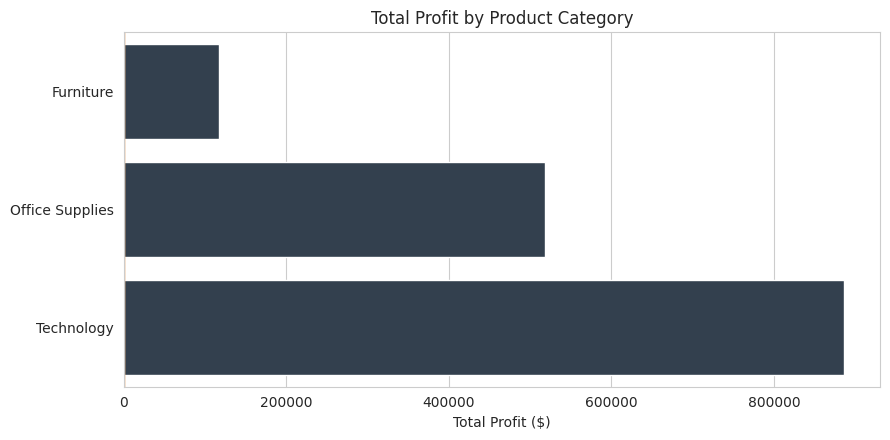

In [17]:
fig, ax = plt.subplots(figsize=(9,4.5))
sns.barplot(data=q1.sort_values('total_profit'), y='product_category', x='total_profit', ax=ax, color='#2E4053')
ax.axvline(0, color='#E67E22', linewidth=1)
ax.set_title('Total Profit by Product Category')
ax.set_xlabel('Total Profit ($)'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('charts/profit_by_category.png', dpi=150)
plt.show()


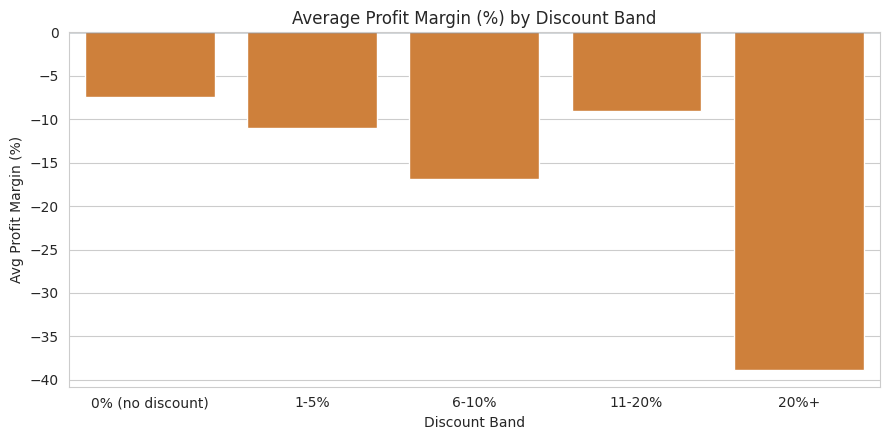

In [18]:
fig, ax = plt.subplots(figsize=(9,4.5))
order = ['0% (no discount)','1-5%','6-10%','11-20%','20%+']
sns.barplot(data=q2, x='discount_band', y='avg_profit_margin_pct', order=order, ax=ax, color='#E67E22')
ax.axhline(0, color='#2E4053', linewidth=1)
ax.set_title('Average Profit Margin (%) by Discount Band')
ax.set_xlabel('Discount Band'); ax.set_ylabel('Avg Profit Margin (%)')
plt.tight_layout()
plt.savefig('charts/margin_by_discount_band.png', dpi=150)
plt.show()


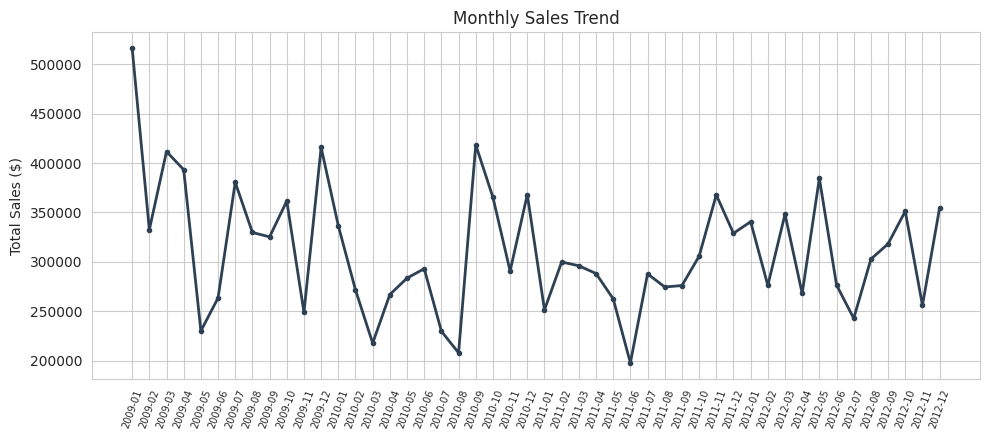

In [19]:
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(q4['order_year_month'], q4['total_sales'], color='#2E4053', linewidth=2, marker='o', markersize=3)
ax.set_title('Monthly Sales Trend')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=70, fontsize=7)
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png', dpi=150)
plt.show()


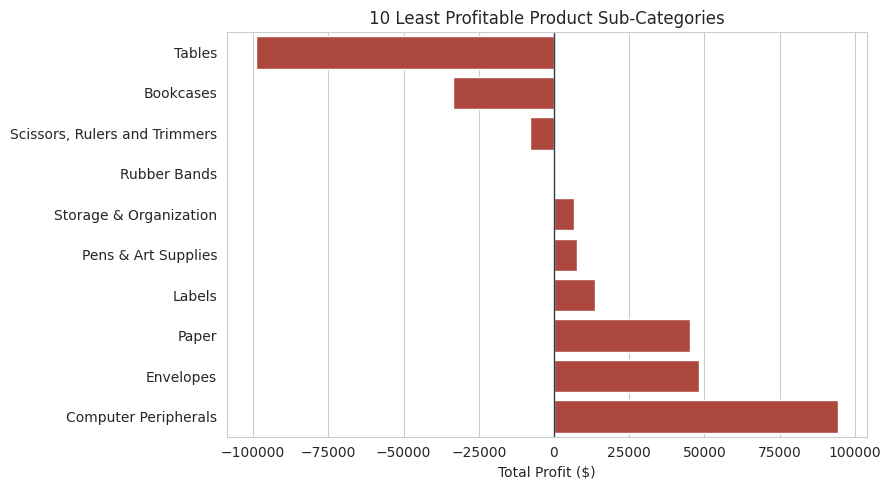

In [20]:
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=q5.sort_values('total_profit'), y='product_sub_category', x='total_profit', ax=ax, color='#C0392B')
ax.axvline(0, color='#2E4053', linewidth=1)
ax.set_title('10 Least Profitable Product Sub-Categories')
ax.set_xlabel('Total Profit ($)'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('charts/worst_subcategories.png', dpi=150)
plt.show()


## 7. Business Recommendations

Based on the analysis above:

1. **Cap discounts around 10-15% on order lines outside of clearance/inventory-clearing situations.** Profit margin declines steadily as discount rate increases, and the 20%+ discount band is where average profit margin turns negative — deep discounting is actively costing money on a meaningful share of orders, not just eating into margin.

2. **Review pricing and cost structure for the lowest-performing sub-categories** identified in Section 5 (Q5) — these are losing money in aggregate even before considering fulfillment costs, and are worth a SKU-level pricing or vendor-cost review rather than broad category-level fixes.

3. **Double down on the top-performing product category and region** — both show consistently positive margins and represent the clearest opportunity to grow revenue without proportionally growing risk.

4. **Investigate the ~19% of order lines sold at a loss as a standing operational metric**, not a one-time finding — tracking "% of orders at a loss" monthly would catch margin erosion early instead of only surfacing it in a retrospective analysis like this one.

5. **Monitor month-over-month sales trend for seasonality** — the volatility in Section 5 (Q4) suggests seasonal demand patterns that could inform inventory and staffing decisions if extended with a full seasonal decomposition.

## 8. Limitations & Next Steps

- This is historical, static data — a production version of this analysis would connect to a live order-management system and refresh on a schedule.
- Profit margin by discount band is a correlational finding, not a causal one — a proper test (e.g., a controlled discount experiment) would be needed to confirm that reducing discounts *causes* higher margins rather than just being associated with categories that already have thinner margins.
- Customer-level analysis (repeat purchase rate, customer lifetime value) was out of scope here but is a natural extension of this dataset.
